# VANET Intrusion Detection System
### ML-Based Attack Classification for V2X Networks

**Dataset:** `v2x_dataset_Main_run.csv` (466,454 rows × 50 columns)  
**Labels:** Normal | Sybil | DDoS | Blackhole  
**Models:** Random Forest + XGBoost with SMOTE for class imbalance

---
## 1. Imports & Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay,
)
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'model_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('All imports loaded successfully.')

All imports loaded successfully.


---
## 2. Load Dataset

In [2]:
t0 = time.time()
df = pd.read_csv('v2x_dataset_Main_run.csv')
print(f'Shape: {df.shape}  |  Loaded in {time.time()-t0:.1f}s')
df.head()

Shape: (466454, 49)  |  Loaded in 3.1s


,timestamp,car_id,event_type,label,pos_x,pos_y,speed_mps,distance_moved,position_changes,avg_speed,...,network_load,sybil_score,ddos_score,blackhole_score,norm_send_rate,norm_recv_rate,norm_bytes_sent,norm_attack_rate,norm_speed,norm_pkt_size
0,0.2,0,beacon_sent,sybil,2415.00,1578.00,0.00000,2884.84,1,0.0,...,1.0,0.0,0,0,0.066667,0.0,0.000092,0.000,0.000000,0.061333
1,0.2,0,sybil_sent,sybil,2424.26,1524.53,7.51562,2884.84,1,0.0,...,2.0,1.0,0,0,0.066667,0.0,0.000184,0.002,0.150312,0.061333
2,0.2,0,sybil_sent,sybil,2585.46,1620.02,1.75702,2884.84,1,0.0,...,3.0,2.0,0,0,0.066667,0.0,0.000276,0.004,0.035140,0.061333
3,0.2,0,sybil_sent,sybil,2336.16,1465.98,17.31850,2884.84,1,0.0,...,4.0,3.0,0,0,0.066667,0.0,0.000368,0.006,0.346370,0.061333
4,0.2,0,sybil_sent,sybil,2552.07,1445.87,4.91019,2884.84,1,0.0,...,5.0,4.0,0,0,0.066667,0.0,0.000460,0.008,0.098204,0.061333


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466454 entries, 0 to 466453
Data columns (total 49 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            466454 non-null  float64
 1   car_id               466454 non-null  int64  
 2   event_type           466454 non-null  object 
 3   label                466454 non-null  object 
 4   pos_x                466454 non-null  float64
 5   pos_y                466454 non-null  float64
 6   speed_mps            466454 non-null  float64
 7   distance_moved       466454 non-null  float64
 8   position_changes     466454 non-null  int64  
 9   avg_speed            466454 non-null  float64
 10  pkt_size_bytes       466454 non-null  int64  
 11  is_fake              466454 non-null  int64  
 12  fake_id              466454 non-null  int64  
 13  my_beacons_sent      466454 non-null  int64  
 14  my_beacons_received  466454 non-null  int64  
 15  my_attack_packets

---
## 3. Exploratory Data Analysis

In [4]:
# Label distribution
label_counts = df['label'].value_counts()
print('Label Distribution:')
print(label_counts)
print(f'\nTotal samples: {len(df):,}')

Label Distribution:
label
normal       280478
sybil        148950
ddos          24677
blackhole     12349
Name: count, dtype: int64

Total samples: 466,454


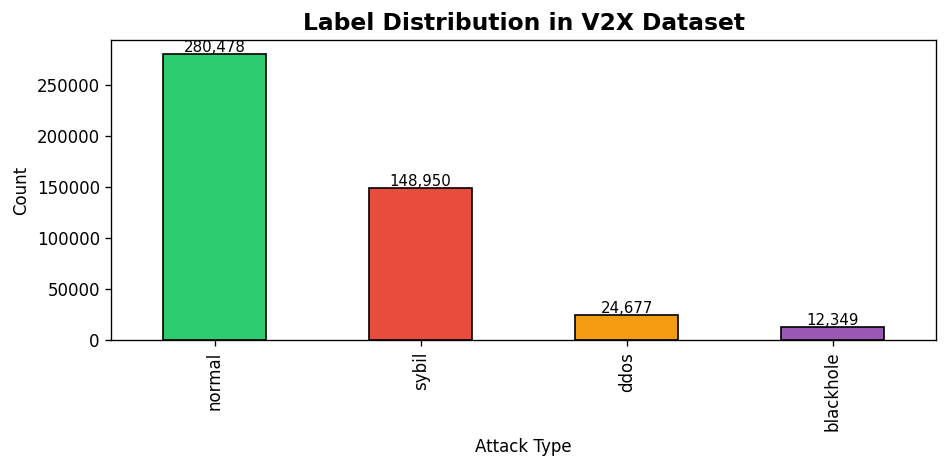

In [5]:
# Label distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
label_counts.plot.bar(ax=ax, color=colors, edgecolor='black')
ax.set_title('Label Distribution in V2X Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Attack Type')
for i, v in enumerate(label_counts):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# Missing values check
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
missing[missing > 0].sort_values(ascending=False) if missing.sum() > 0 else print('No missing values!')

Total missing values: 0
No missing values!


In [7]:
# Basic statistics
df.describe()

,timestamp,car_id,pos_x,pos_y,speed_mps,distance_moved,position_changes,avg_speed,pkt_size_bytes,is_fake,...,network_load,sybil_score,ddos_score,blackhole_score,norm_send_rate,norm_recv_rate,norm_bytes_sent,norm_attack_rate,norm_speed,norm_pkt_size
count,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,...,466454.000000,466454.000000,466454.0,466454.0,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000
mean,205.019362,32.230458,1718.343036,1672.900656,13.310267,4166.229548,1046.239113,11.736284,89.564373,0.133079,...,525.693995,16.000743,0.0,0.0,0.651429,0.756072,0.262862,0.032001,0.266205,0.059710
std,98.591613,31.320812,702.683086,286.642559,3.743094,1175.933747,724.199121,2.853585,14.769762,0.339660,...,139.223411,23.374739,0.0,0.0,0.109608,0.198966,0.321099,0.046749,0.074862,0.009847
min,0.200000,0.000000,0.341558,1018.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,131.400000,3.000000,1192.582500,1394.642500,12.743200,3381.150000,417.000000,11.712500,92.000000,0.000000,...,425.678000,0.000000,0.0,0.0,0.667058,0.666667,0.049404,0.000000,0.254863,0.061333
50%,205.200000,24.000000,1914.210000,1670.930000,13.910800,4099.950000,957.000000,12.743400,92.000000,0.000000,...,547.879000,0.000000,0.0,0.0,0.667319,0.667335,0.120428,0.000000,0.278215,0.061333
75%,280.075000,53.000000,2372.520000,1926.850000,13.962300,5020.960000,1618.000000,13.190800,92.000000,0.000000,...,650.093000,50.016800,0.0,0.0,0.668075,1.000000,0.297528,0.100034,0.279247,0.061333
max,397.500000,132.000000,2649.620000,2319.490000,29.999100,6299.120000,2860.000000,13.572300,92.000000,1.000000,...,715.585000,100.000000,0.0,0.0,1.000000,1.000000,1.000000,0.200000,0.599983,0.061333


---
## 4. Preprocessing

In [8]:
# Drop columns that leak attack identity or are non-predictive
LEAK_COLS = [
    'event_type', 'car_id', 'is_fake', 'fake_id',
    'sybil_score', 'ddos_score', 'blackhole_score',
]
df.drop(columns=[c for c in LEAK_COLS if c in df.columns], inplace=True)
print(f'Dropped leaky / ID columns: {LEAK_COLS}')
print(f'Remaining columns: {df.shape[1]}')

Dropped leaky / ID columns: ['event_type', 'car_id', 'is_fake', 'fake_id', 'sybil_score', 'ddos_score', 'blackhole_score']
Remaining columns: 42


In [9]:
# Encode target labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
label_names = list(le.classes_)
print(f'Label encoding: {dict(zip(label_names, le.transform(label_names)))}')

Label encoding: {'blackhole': np.int64(0), 'ddos': np.int64(1), 'normal': np.int64(2), 'sybil': np.int64(3)}


In [10]:
# Feature / Target split
FEATURE_COLS = [c for c in df.columns if c not in ('label', 'label_enc')]
X = df[FEATURE_COLS].copy()
y = df['label_enc'].copy()

# Handle missing values
if X.isnull().sum().sum() > 0:
    X.fillna(X.median(), inplace=True)
    print('Filled missing values with column medians.')

# Handle remaining object columns
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'Encoding categorical columns: {obj_cols}')
    for col in obj_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

print(f'Final feature matrix: {X.shape}')

Final feature matrix: (466454, 41)


---
## 5. Feature Selection (Mutual Information)

In [11]:
# Compute MI scores on a 50K sample for speed
sample_idx = np.random.RandomState(42).choice(len(X), size=min(50_000, len(X)), replace=False)
mi_scores = mutual_info_classif(X.iloc[sample_idx], y.iloc[sample_idx], random_state=42)
mi_df = pd.DataFrame({'feature': FEATURE_COLS, 'mi_score': mi_scores}).sort_values(
    'mi_score', ascending=False
)
mi_df.head(15)

,feature,mi_score
22,throughput_bps,0.734875
23,send_recv_ratio,0.733379
15,beacon_recv_rate,0.731003
36,norm_recv_rate,0.728519
38,norm_attack_rate,0.629338
25,fake_ratio,0.629264
10,my_attack_packets,0.626306
11,my_fake_ids_sent,0.625676
16,attack_rate,0.625545
37,norm_bytes_sent,0.566519


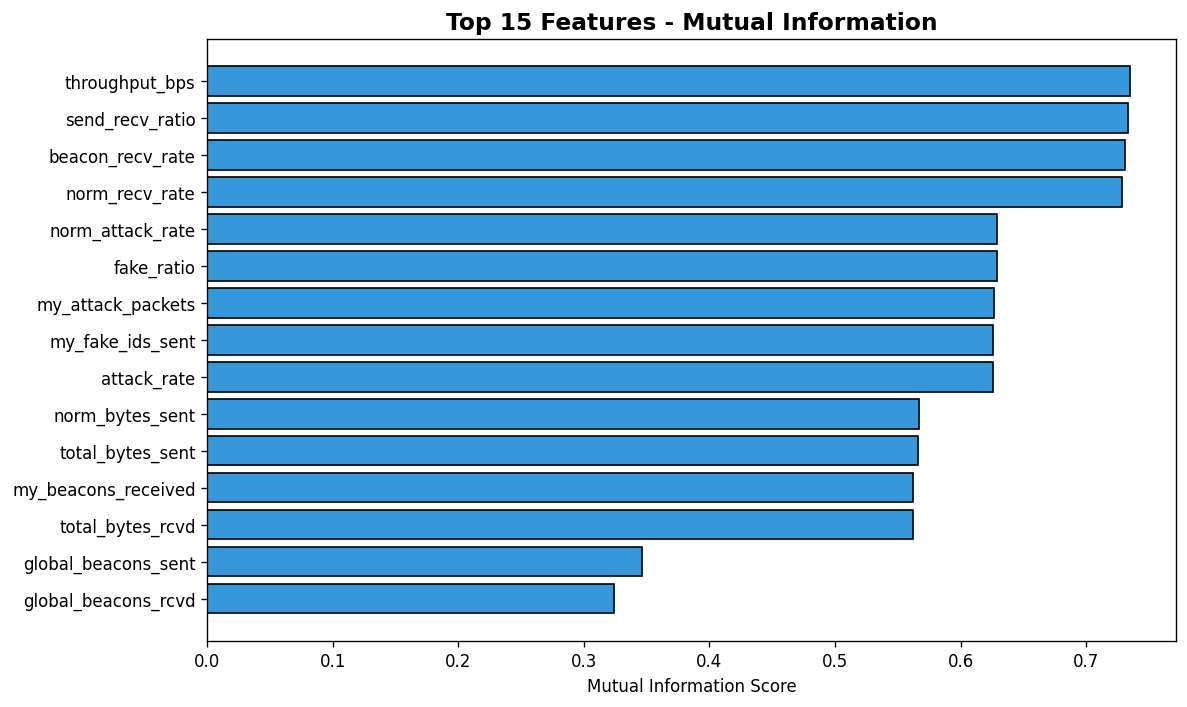

In [12]:
# Feature importance chart
fig, ax = plt.subplots(figsize=(10, 6))
top15 = mi_df.head(15)
ax.barh(top15['feature'][::-1], top15['mi_score'][::-1], color='#3498db', edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 15 Features - Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Select top features (MI > 0.01)
TOP_FEATURES = mi_df.loc[mi_df['mi_score'] > 0.01, 'feature'].tolist()
if len(TOP_FEATURES) < 10:
    TOP_FEATURES = mi_df.head(15)['feature'].tolist()
print(f'Selected {len(TOP_FEATURES)} features with MI > 0.01')
X = X[TOP_FEATURES]
X.shape

Selected 34 features with MI > 0.01


(466454, 34)

---
## 6. Train/Test Split & SMOTE Balancing

In [14]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: (373163, 34)  |  Test: (93291, 34)


In [15]:
# SMOTE to balance training set
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)
print(f'Before SMOTE: {X_train_sc.shape}')
print(f'After SMOTE:  {X_train_res.shape}')
print(f'\nClass counts after SMOTE:')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_names[u]}: {c:,}')

Before SMOTE: (373163, 34)
After SMOTE:  (897528, 34)

Class counts after SMOTE:
  blackhole: 224,382
  ddos: 224,382
  normal: 224,382
  sybil: 224,382


---
## 7. Model Training & Evaluation

In [16]:
results = {}

def evaluate_model(name, model, Xtr, ytr, Xte, yte):
    """Train, predict, and report metrics."""
    t_start = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t_start

    y_pred = model.predict(Xte)
    acc = accuracy_score(yte, y_pred)
    f1_w = f1_score(yte, y_pred, average='weighted')
    f1_mac = f1_score(yte, y_pred, average='macro')

    results[name] = {
        'model': model, 'accuracy': acc,
        'f1_weighted': f1_w, 'f1_macro': f1_mac,
        'train_time': train_time, 'y_pred': y_pred,
    }
    return acc, f1_w, f1_mac, train_time, y_pred

print('Evaluation function ready.')

Evaluation function ready.


### 7a. Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=25,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
acc, f1_w, f1_mac, t, y_pred_rf = evaluate_model(
    'Random Forest', rf, X_train_res, y_train_res, X_test_sc, y_test
)
print(f'Accuracy:       {acc:.4f}')
print(f'F1 (weighted):  {f1_w:.4f}')
print(f'F1 (macro):     {f1_mac:.4f}')
print(f'Training time:  {t:.1f}s')

Accuracy:       1.0000
F1 (weighted):  1.0000
F1 (macro):     1.0000
Training time:  110.7s


In [18]:
# Random Forest - Classification Report
print(classification_report(y_test, y_pred_rf, target_names=label_names))

              precision    recall  f1-score   support

   blackhole       1.00      1.00      1.00      2470
        ddos       1.00      1.00      1.00      4935
      normal       1.00      1.00      1.00     56096
       sybil       1.00      1.00      1.00     29790

    accuracy                           1.00     93291
   macro avg       1.00      1.00      1.00     93291
weighted avg       1.00      1.00      1.00     93291



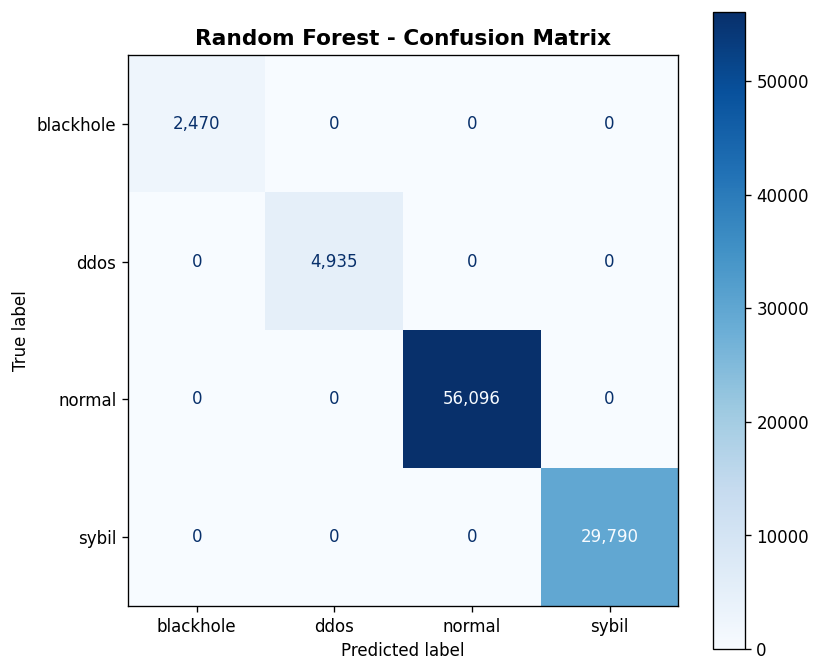

In [19]:
# Random Forest - Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7b. XGBoost

In [20]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=10,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, objective='multi:softmax',
    num_class=len(label_names), eval_metric='mlogloss',
    use_label_encoder=False, random_state=42, n_jobs=-1,
)
acc, f1_w, f1_mac, t, y_pred_xgb = evaluate_model(
    'XGBoost', xgb, X_train_res, y_train_res, X_test_sc, y_test
)
print(f'Accuracy:       {acc:.4f}')
print(f'F1 (weighted):  {f1_w:.4f}')
print(f'F1 (macro):     {f1_mac:.4f}')
print(f'Training time:  {t:.1f}s')

Accuracy:       1.0000
F1 (weighted):  1.0000
F1 (macro):     1.0000
Training time:  72.0s


In [21]:
# XGBoost - Classification Report
print(classification_report(y_test, y_pred_xgb, target_names=label_names))

              precision    recall  f1-score   support

   blackhole       1.00      1.00      1.00      2470
        ddos       1.00      1.00      1.00      4935
      normal       1.00      1.00      1.00     56096
       sybil       1.00      1.00      1.00     29790

    accuracy                           1.00     93291
   macro avg       1.00      1.00      1.00     93291
weighted avg       1.00      1.00      1.00     93291



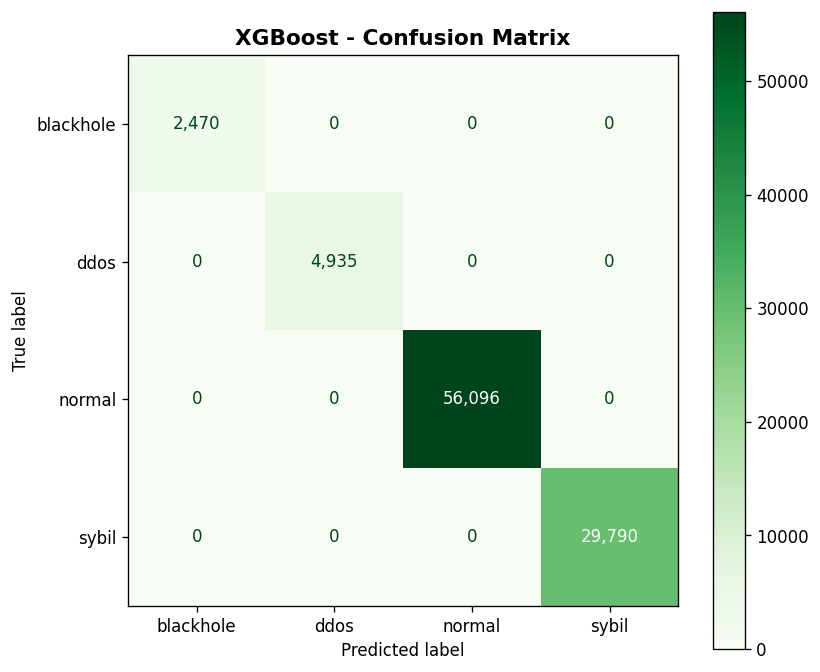

In [22]:
# XGBoost - Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Greens', values_format=',')
ax.set_title('XGBoost - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Model Comparison

In [23]:
# Side-by-side comparison
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'F1 (Weighted)': r['f1_weighted'],
        'F1 (Macro)': r['f1_macro'],
        'Train Time (s)': round(r['train_time'], 1),
    }
    for name, r in results.items()
}).T
comparison

,Accuracy,F1 (Weighted),F1 (Macro),Train Time (s)
Random Forest,1.0,1.0,1.0,110.7
XGBoost,1.0,1.0,1.0,72.0


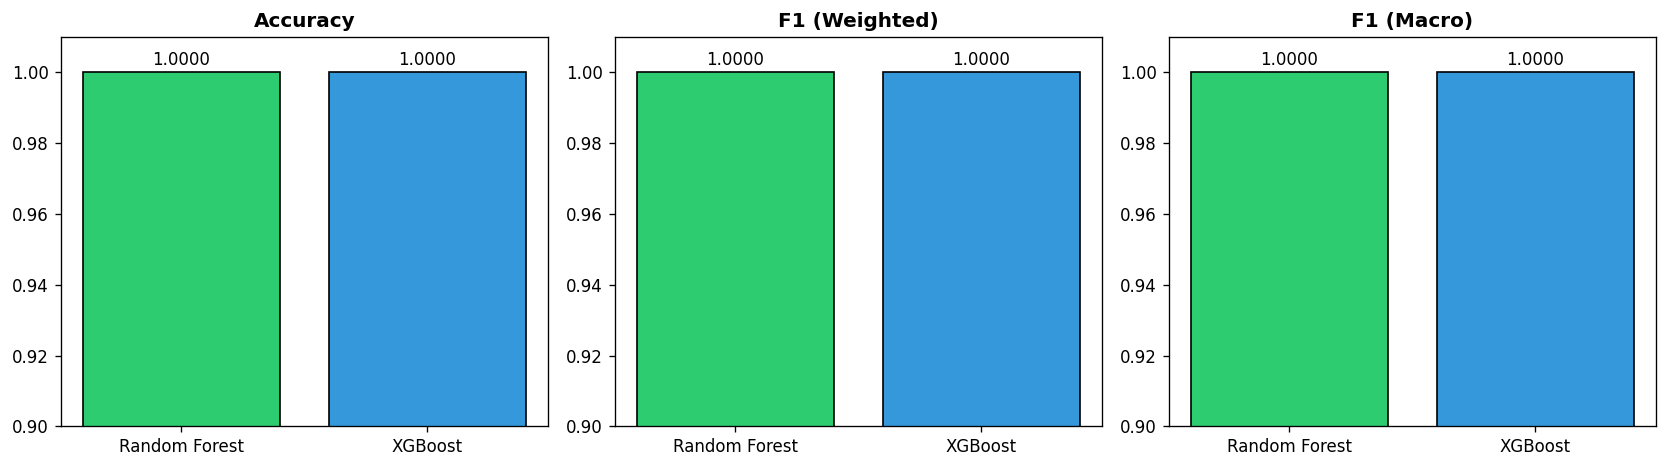

In [24]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_names = list(results.keys())
metrics = ['accuracy', 'f1_weighted', 'f1_macro']
titles = ['Accuracy', 'F1 (Weighted)', 'F1 (Macro)']

for ax, metric, title in zip(axes, metrics, titles):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=['#2ecc71', '#3498db'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0.9, 1.01)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
                f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 9. Save Best Model & Artifacts

In [25]:
# Pick best model by weighted F1
best_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_model = results[best_name]['model']

# Save everything
joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'best_model.joblib'))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))
joblib.dump(le, os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))
joblib.dump(TOP_FEATURES, os.path.join(OUTPUT_DIR, 'feature_list.joblib'))

print(f'Best model: {best_name}')
print(f'Accuracy:       {results[best_name]["accuracy"]:.4f}')
print(f'F1 (weighted):  {results[best_name]["f1_weighted"]:.4f}')
print(f'F1 (macro):     {results[best_name]["f1_macro"]:.4f}')
print(f'Features used:  {len(TOP_FEATURES)}')
print(f'\nAll artifacts saved to: {OUTPUT_DIR}/')

Best model: Random Forest
Accuracy:       1.0000
F1 (weighted):  1.0000
F1 (macro):     1.0000
Features used:  34

All artifacts saved to: model_outputs/


---
## 10. Inference Demo
Quick demo showing how to load and use the saved model on new data.

In [26]:
# Load saved artifacts
loaded_model = joblib.load(os.path.join(OUTPUT_DIR, 'best_model.joblib'))
loaded_scaler = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.joblib'))
loaded_le = joblib.load(os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))
loaded_features = joblib.load(os.path.join(OUTPUT_DIR, 'feature_list.joblib'))

# Predict on 5 random test samples
sample = X_test.sample(5, random_state=123)
sample_sc = loaded_scaler.transform(sample[loaded_features])
preds = loaded_model.predict(sample_sc)
pred_labels = loaded_le.inverse_transform(preds)

actual_labels = loaded_le.inverse_transform(y_test.loc[sample.index].values)

pd.DataFrame({
    'Predicted': pred_labels,
    'Actual': actual_labels,
    'Correct': pred_labels == actual_labels
}, index=sample.index)

,Predicted,Actual,Correct
82445,ddos,ddos,True
202881,normal,normal,True
128929,normal,normal,True
390786,normal,normal,True
29657,sybil,sybil,True
